1. CONFIGURANDO ENTORNO Y CARGANDO MODELO...
Modelo encontrado: /content/unet_float32.tflite
Input shape: [  1 224 224   3] | dtype: <class 'numpy.float32'>
Output shape: [  1 224 224   3] | dtype: <class 'numpy.float32'>

CARGAR IMAGEN

Opciones:
1. Si tienes una imagen en /content/, escribe el nombre abajo
2. Si no, sube una imagen manualmente

Archivos disponibles en /content/:
   Imágenes encontradas:
   1. gato1.jpeg
   2. perro1.jpeg
   3. segmentation_result.png

Elige un número (1-3) o escribe el nombre: 2

Cargando imagen: /content/perro1.jpeg
   Tamaño original: (452, 679)

3. EJECUTANDO SEGMENTACION...
Inferencia completada.

4. GENERANDO VISUALIZACION...


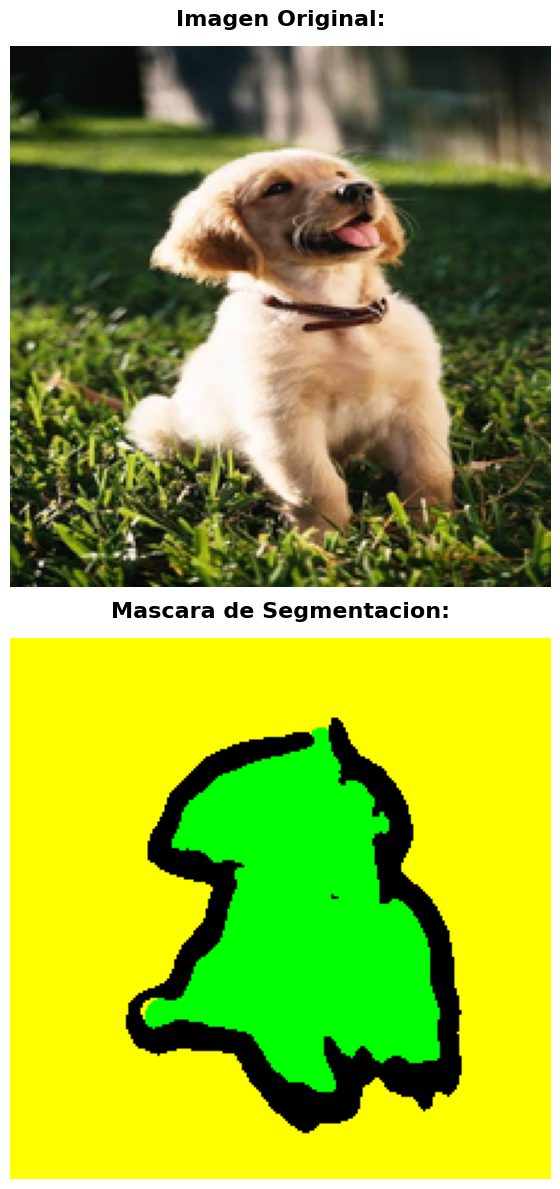


Estadisticas de segmentacion:
   - Mascota (Verde): 10268 pixels (20.5%)
   - Borde (Amarillo): 34484 pixels (68.7%)
   - Fondo (Negro): 5424 pixels (10.8%)

Imagen guardada en: /content/segmentation_result.png
Puede descargarla con: files.download('/content/segmentation_result.png')


In [20]:
# =====================================================
# PIPELINE COMPLETO: CARGA, INFERENCIA Y VISUALIZACION
# Estilo App Android (Imagen Original + Mascara Pura)
# =====================================================

import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

print("="*60)
print("1. CONFIGURANDO ENTORNO Y CARGANDO MODELO...")
print("="*60)

# 1. Cargar Modelo TFLite
tflite_path = '/content/unet_float32.tflite'

if not os.path.exists(tflite_path):
    raise FileNotFoundError(f"ERROR: No se encontro el modelo en {tflite_path}. Suba el archivo a /content/")

print(f"Modelo encontrado: {tflite_path}")
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print(f"Input shape: {input_details[0]['shape']} | dtype: {input_details[0]['dtype']}")
print(f"Output shape: {output_details[0]['shape']} | dtype: {output_details[0]['dtype']}")

# =====================================================
# 2. FUNCIONES DE PRE/POST-PROCESAMIENTO
# =====================================================

def preprocess_image(img):
    """Preprocesamiento con normalizacion ImageNet y float32"""
    img_resized = img.resize((224, 224), Image.Resampling.LANCZOS)
    img_array = np.array(img_resized).astype(np.float32) / 255.0

    # Stats de ImageNet (forzando float32 para evitar el error de TFLite)
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img_normalized = ((img_array - mean) / std).astype(np.float32)

    return np.expand_dims(img_normalized, axis=0), img_resized

# =====================================================
# 3. CARGAR IMAGEN DESDE /content/
# =====================================================

print("\n" + "="*60)
print("CARGAR IMAGEN")

print("\nOpciones:")
print("1. Si tienes una imagen en /content/, escribe el nombre abajo")
print("2. Si no, sube una imagen manualmente")
print("="*60)

# Listar archivos en /content/
print("\nArchivos disponibles en /content/:")
files_in_content = os.listdir('/content/')
image_files = [f for f in files_in_content if f.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')) and f != 'unet_float32.tflite']

if image_files:
    print("   Imágenes encontradas:")
    for i, img_file in enumerate(image_files, 1):
        print(f"   {i}. {img_file}")

    # Usar la primera imagen encontrada o preguntar
    if len(image_files) == 1:
        img_path = f'/content/{image_files[0]}'
        print(f"\nUsando: {img_path}")
    else:
        # Preguntar cuál usar
        choice = input(f"\nElige un número (1-{len(image_files)}) o escribe el nombre: ")
        try:
            idx = int(choice) - 1
            img_path = f'/content/{image_files[idx]}'
        except:
            img_path = f'/content/{choice}'
else:
    print("\nNo se encontraron imágenes en /content/")
    print("   Sube una imagen arrastrándola a la carpeta de archivos")
    img_path = None

# Cargar y procesar imagen
if img_path and os.path.exists(img_path):
    print(f"\nCargando imagen: {img_path}")
    img = Image.open(img_path).convert('RGB')
    print(f"   Tamaño original: {img.size}")

# =====================================================
# 4. EJECUTAR INFERENCIA
# =====================================================

print("\n" + "="*60)
print("3. EJECUTANDO SEGMENTACION...")
print("="*60)

input_data, img_resized = preprocess_image(img)
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

# Obtener mascara (argmax)
if len(output.shape) == 4:
    mask = np.argmax(output[0], axis=-1)
else:
    mask = np.argmax(output[0], axis=0)

print("Inferencia completada.")

# =====================================================
# 5. VISUALIZACION ESTILO APP ANDROID
# =====================================================

print("\n" + "="*60)
print("4. GENERANDO VISUALIZACION...")
print("="*60)

# Crear imagen RGB para la mascara con los colores exactos
mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
mask_rgb[mask == 0] = [0, 255, 0]      # Verde brillante (Mascota)
mask_rgb[mask == 1] = [255, 255, 0]    # Amarillo (Borde)
mask_rgb[mask == 2] = [0, 0, 0]        # Negro (Fondo)

# Configurar grafico vertical (estilo pantalla de celular)
fig, axes = plt.subplots(2, 1, figsize=(6, 12))

# Imagen Original
axes[0].imshow(img_resized)
axes[0].set_title("Imagen Original:", fontsize=16, fontweight='bold', pad=15)
axes[0].axis('off')

# Mascara de Segmentacion
axes[1].imshow(mask_rgb)
axes[1].set_title("Mascara de Segmentacion:", fontsize=16, fontweight='bold', pad=15)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/segmentation_result.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Estadisticas finales
total_pixels = mask.size
print("\nEstadisticas de segmentacion:")
print(f"   - Mascota (Verde): {np.sum(mask == 0)} pixels ({np.sum(mask == 0)/total_pixels*100:.1f}%)")
print(f"   - Borde (Amarillo): {np.sum(mask == 1)} pixels ({np.sum(mask == 1)/total_pixels*100:.1f}%)")
print(f"   - Fondo (Negro): {np.sum(mask == 2)} pixels ({np.sum(mask == 2)/total_pixels*100:.1f}%)")

print("\nImagen guardada en: /content/segmentation_result.png")
print("Puede descargarla con: files.download('/content/segmentation_result.png')")